# Modelos de regresión

**Autor/es:**
+ Christian Jamett
+ José Manríquez

**Correos Electrónicos:**
+ christian.jamett2101@alumnos.ubiobio.cl
+ jose.manriquez2101@alumnos.ubiobio.cl

**Fecha de Creación:** Octubre de 2024  
**Versión:** 1.0

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 - parte 1 de la asignatura de Inteligencia Artificial de la carrera de Ingeniería civil en informática de la Universidad del Bío Bío - Sede Concepción


In [1]:
# Descargar el archivo a la carpeta data
!wget https://raw.githubusercontent.com/JaznaLaProfe/InteligenciaArtificial/main/data/walmart.csv.zip

# Descomprimir el archivo directamente dentro de la carpeta data
!unzip -q walmart.csv.zip

# Eliminar el archivo zip
!rm walmart.csv.zip

# Eliminar la carpeta __MACOSX si se creó
!rm -rf __MACOSX

--2024-10-07 07:50:42--  https://raw.githubusercontent.com/JaznaLaProfe/InteligenciaArtificial/main/data/walmart.csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4493735 (4.3M) [application/zip]
Saving to: ‘walmart.csv.zip’

walmart.csv.zip     100%[===================>]   4.29M  --.-KB/s    in 0.08s   

2024-10-07 07:50:42 (51.1 MB/s) - ‘walmart.csv.zip’ saved [4493735/4493735]

replace walmart.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


# Descripción de la data

El conjunto de datos proporciona información sobre:
+ Store: número de identificación de la tienda.
+ Date: semana en la que ocurrieron las ventas.
+ Weekly_Sales: monto total de ventas en esa tienda durante la semana.
+ Holiday_Flag: Un indicador binario que muestra si la semana coincide con un feriado importante.
+ Temperature: temperatura registrada en el día de la venta.
+ Fuel_Price: El precio del combustible en la región.
+ CPI: índice de precios al consumidor en la región.
+ Unemployment: tasa de desempleo prevalente en ese momento.
+ Event_Type: tipo de evento asociado a la semana, como Super Bowl, Labour Day, Thanksgiving, Christmas o semana normal.



# Contexto del negocio

Una cadena de tiendas minoristas desea mejorar la precisión en la planificación de inventarios y recursos mediante la redicción del monto de las ventas semanales en cada una de sus sucursales. Para lograr esto, se cuenta con un set de datos que incluye múltiples variables relevantes, como las ventas semanales históricas, las condiciones económicas y eventos especiales que podrían impactar el comportamiento de los consumidores.

# Objetivo

Desarrollar modelos de regresión que permitan predecir el monto de las ventas semanales para cada tienda, basándose en variables que reflejan tanto factores económicos como eventos estacionales y externos. Esta predicción permitirá a la cadena anticiparse a fluctuaciones en la demanda, optimizando así su cadena de suministro y maximizando la eficiencia operativa.

# Preparación del entorno

Cargas las bibliotecas necesarias para el trabajo

In [2]:
import pandas as pd
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_log_error
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carga de la data

In [3]:
# Leer el archivo CSV sin la columna de índice no deseada
data = pd.read_csv("walmart.csv", sep=",")

# Fase 1 - Comprensión del negocio

Una cadena de tiendas minoristas desea mejorar la precisión en la planificación de inventarios y recursos mediante la redicción del monto de las ventas semanales en cada una de sus sucursales. Para lograr esto, se cuenta con un set de datos que incluye múltiples variables relevantes, como las ventas semanales históricas, las condiciones económicas y eventos especiales que podrían impactar el comportamiento de los consumidores.

# Fase 2 - Comprensión de los datos

In [4]:
# Obtener la cantidad de filas y columnas (observaciones y características de los datos)
data.shape


(421570, 18)

In [5]:
# Nombre de las columnas
data.columns

Index(['Unnamed: 0', 'Store', 'Date', 'IsHoliday', 'Dept', 'Weekly_Sales',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size',
       'Event_Type'],
      dtype='object')

In [6]:
# Obtiene las primeras 5 observaciones
data.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Event_Type
0,0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,Normal
1,1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,Normal
2,2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,Normal
3,3,1,2010-02-05,0,45.0,37.44,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,Normal
4,4,1,2010-02-05,0,28.0,1085.29,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,Normal


In [7]:
# Obtiene detalles de las columnas (características de los diamantes)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    421570 non-null  int64  
 1   Store         421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   IsHoliday     421570 non-null  int64  
 4   Dept          421570 non-null  float64
 5   Weekly_Sales  421570 non-null  float64
 6   Temperature   421570 non-null  float64
 7   Fuel_Price    421570 non-null  float64
 8   MarkDown1     421570 non-null  float64
 9   MarkDown2     421570 non-null  float64
 10  MarkDown3     421570 non-null  float64
 11  MarkDown4     421570 non-null  float64
 12  MarkDown5     421570 non-null  float64
 13  CPI           421570 non-null  float64
 14  Unemployment  421570 non-null  float64
 15  Type          421570 non-null  int64  
 16  Size          421570 non-null  int64  
 17  Event_Type    421570 non-null  object 
dtypes: f

In [8]:
# Obtiene la cantidad de registros con valores nulos
data.isna().sum()

,0
Unnamed: 0,0
Store,0
Date,0
IsHoliday,0
Dept,0
Weekly_Sales,0
Temperature,0
Fuel_Price,0
MarkDown1,0
MarkDown2,0


In [9]:
# Usaremos un método resumen de estadísticas numéricas
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,421570.0,211611.321278,122195.149363,0.000,105782.250000,211603.50000,317424.750000,423285.000000
Store,421570.0,22.200546,12.785297,1.000,11.000000,22.00000,33.000000,45.000000
IsHoliday,421570.0,0.070358,0.255750,0.000,0.000000,0.00000,0.000000,1.000000
Dept,421570.0,44.260317,30.492054,1.000,18.000000,37.00000,74.000000,99.000000
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.940,2079.650000,7612.03000,20205.852500,693099.360000
Temperature,421570.0,60.090059,18.447931,-2.060,46.680000,62.09000,74.280000,100.140000
Fuel_Price,421570.0,3.361027,0.458515,2.472,2.933000,3.45200,3.738000,4.468000
MarkDown1,421570.0,2590.074819,6052.385934,0.000,0.000000,0.00000,2809.050000,88646.760000
MarkDown2,421570.0,879.974298,5084.538801,-265.760,0.000000,0.00000,2.200000,104519.540000
MarkDown3,421570.0,468.087665,5528.873453,-29.100,0.000000,0.00000,4.540000,141630.610000


In [10]:
# Obtiene la correlación de las variables con weekly_sales (la variable que se pretende predecir)
corr_matrix = data[data.describe().columns].corr()
corr_matrix["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.243828
Type,0.182242
Dept,0.148032
MarkDown5,0.050465
MarkDown1,0.047172
MarkDown3,0.038562
MarkDown4,0.037467
MarkDown2,0.020716
IsHoliday,0.012774


In [11]:
corr_matrix = data[data.describe().columns].corr()
corr_matrix["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.243828
Type,0.182242
Dept,0.148032
MarkDown5,0.050465
MarkDown1,0.047172
MarkDown3,0.038562
MarkDown4,0.037467
MarkDown2,0.020716
IsHoliday,0.012774


###Justificación variables numéricas

Basandome en la tabla de correlación que tienen las variables independientes respecto a la dependiente, donde se pueden ver las seleccionadas más abajo, donde la idea fue quitar todas las que estuvieran bajo 0,1.
y en la fase 3 se explicará un poco sobre Date.

In [12]:
# Elimina las columnas con cero aporte analítico
df_final = data.drop(['Unnamed: 0', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                      'IsHoliday','Fuel_Price', 'Temperature', 'CPI', 'Unemployment','Store'], axis=1)

In [13]:
df_final.columns

Index(['Date', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Event_Type'], dtype='object')

In [14]:
# Obtiene la correlación de las variables con weekly_sales (la variable que se pretende predecir)
corr_matrix = df_final[df_final.describe().columns].corr()
corr_matrix["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.243828
Type,0.182242
Dept,0.148032


In [15]:
# Obtiene registros que incumplen con reglas naturales del negocio
df_final.query('Size<=0 or Weekly_Sales<0')

,Date,Dept,Weekly_Sales,Type,Size,Event_Type
182,2010-02-19,47.0,-863.00,3,151315,Normal
429,2010-03-12,47.0,-698.00,3,151315,Normal
2555,2010-10-08,47.0,-58.00,3,151315,Normal
3632,2011-01-21,54.0,-50.00,3,151315,Normal
4382,2011-04-08,47.0,-298.00,3,151315,Normal
...,...,...,...,...,...,...
419972,2012-05-18,49.0,-3.97,2,118221,Normal
420031,2012-05-25,49.0,-4.97,2,118221,Normal
420370,2012-06-29,49.0,-34.00,2,118221,Normal
420736,2012-08-03,49.0,-1.91,2,118221,Normal


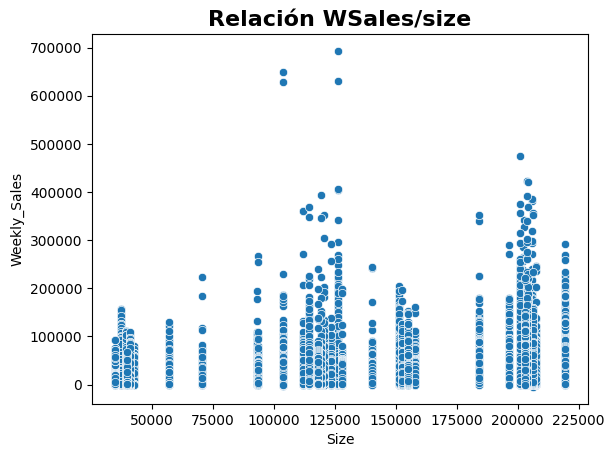

In [16]:
sns.scatterplot(x=df_final.Size , y=df_final.Weekly_Sales)
plt.title("Relación WSales/size", fontsize=16, fontweight="bold")
plt.show()

###Revisión de datos atípicos

In [17]:
len(df_final.query('Weekly_Sales>250000'))

62

In [18]:
len(df_final.query('Weekly_Sales>150000'))

1147

In [19]:
#Valores que son imposibles, aunque esten registrados
len(df_final.query('Weekly_Sales<0'))

1285

In [20]:
len(df_final.query('Size<=0'))

0

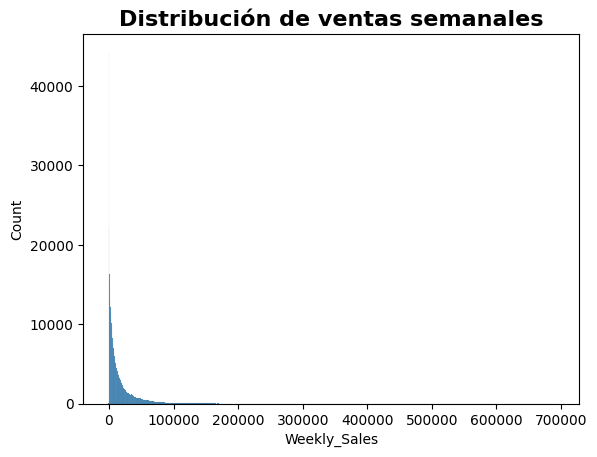

In [21]:
sns.histplot(df_final.Weekly_Sales)
plt.title("Distribución de ventas semanales", fontsize=16, fontweight="bold")
plt.show()

# Fase 3 - Preparación de los datos

##Tratamiento de valores numéricos

Weekly Sales, con la seguridad de que no pueden ser negativos y valores atípicos aproximados.

In [22]:
# Identificación de los registros
df_final.query('Weekly_Sales<0 or Weekly_Sales>150000')

,Date,Dept,Weekly_Sales,Type,Size,Event_Type
182,2010-02-19,47.0,-863.00,3,151315,Normal
429,2010-03-12,47.0,-698.00,3,151315,Normal
2555,2010-10-08,47.0,-58.00,3,151315,Normal
2944,2010-11-19,92.0,157621.22,3,151315,Normal
3039,2010-11-26,72.0,196810.42,3,151315,Thanksgiving
...,...,...,...,...,...,...
419972,2012-05-18,49.0,-3.97,2,118221,Normal
420031,2012-05-25,49.0,-4.97,2,118221,Normal
420370,2012-06-29,49.0,-34.00,2,118221,Normal
420736,2012-08-03,49.0,-1.91,2,118221,Normal


In [23]:
# Obtiene los índices donde están ubicados los atípicos
df_final.query('Weekly_Sales<0 or Weekly_Sales>150000').index

Index([   182,    429,   2555,   2944,   3039,   3045,   3228,   3303,   3344,
         3632,
       ...
       418228, 418307, 418376, 418502, 418940, 419972, 420031, 420370, 420736,
       421131],
      dtype='int64', length=2432)

In [24]:
# Eliminación
df_final.drop(df_final.query('Weekly_Sales<0 or Weekly_Sales>150000').index, inplace=True)

In [25]:
df_final.head()

,Date,Dept,Weekly_Sales,Type,Size,Event_Type
0,2010-02-05,1.0,24924.50,3,151315,Normal
1,2010-02-05,26.0,11737.12,3,151315,Normal
2,2010-02-05,17.0,13223.76,3,151315,Normal
3,2010-02-05,45.0,37.44,3,151315,Normal
4,2010-02-05,28.0,1085.29,3,151315,Normal


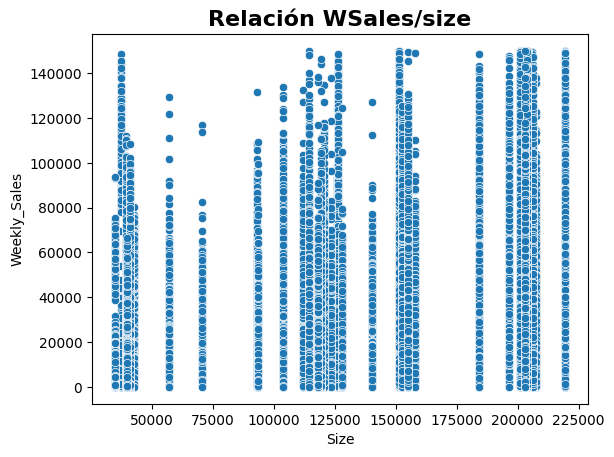

In [26]:
sns.scatterplot(x=df_final.Size , y=df_final.Weekly_Sales)
plt.title("Relación WSales/size", fontsize=16, fontweight="bold")
plt.show()

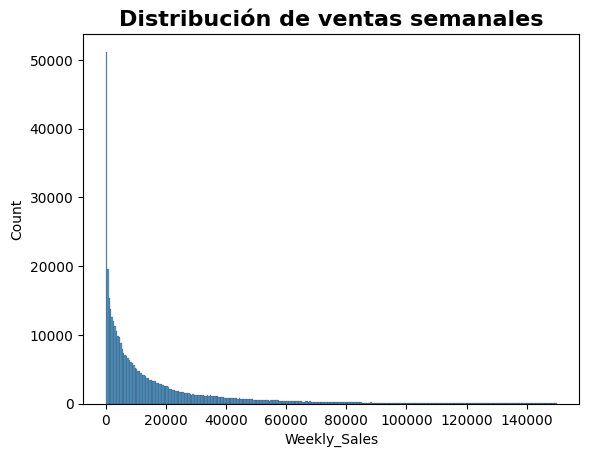

In [27]:
sns.histplot(df_final.Weekly_Sales)
plt.title("Distribución de ventas semanales", fontsize=16, fontweight="bold")
plt.show()

##Tratamiento de variables categóricas

  Entre nuestras variables categoricas estan Event_type y Date, a las cuales le aplicaremos alternativas de transformación.

In [28]:
#Acá podemos identificar las variables de tipo object
df_final.describe(include = np.object_)

,Date,Event_Type
count,419138,419138
unique,143,5
top,2012-02-17,Normal
freq,2993,389727


Antes de pasar a las categoricas guardar una versión para solo variables numericas.

In [29]:
# Respalda el data frame limpio original para uso de solo variables numericas
original_dt_final = df_final.copy()
original_dt_final = original_dt_final.drop(['Event_Type', 'Date'], axis=1)
original_dt_final.head()

,Dept,Weekly_Sales,Type,Size
0,1.0,24924.50,3,151315
1,26.0,11737.12,3,151315
2,17.0,13223.76,3,151315
3,45.0,37.44,3,151315
4,28.0,1085.29,3,151315


###Justificación y uso de Alternativa 0

**En Event_Type se usará get_dummies de forma manual, que es la variable seleccionada como categorica, debido a que es la única como object junto a Date, pero Date se subdividirá para trabajarla como numerica**

In [30]:
print(df_final.columns)

Index(['Date', 'Dept', 'Weekly_Sales', 'Type', 'Size', 'Event_Type'], dtype='object')


In [31]:
# Creación de variables Dummy
df_final.Event_Type.unique()

array(['Normal', 'Super Bowl', 'Labour Day', 'Thanksgiving', 'Christmas'],
      dtype=object)

In [32]:
#Se asigna valor a cada tipo de evento
df_final['Event_Type'] = df_final['Event_Type'].replace({"Normal": 0, "Super Bowl": 1, "Labour Day": 2, "Thanksgiving": 3, "Christmas": 4})
df_final.head()


<ipython-input-32-e86d3e334037>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final['Event_Type'] = df_final['Event_Type'].replace({"Normal": 0, "Super Bowl": 1, "Labour Day": 2, "Thanksgiving": 3, "Christmas": 4})


,Date,Dept,Weekly_Sales,Type,Size,Event_Type
0,2010-02-05,1.0,24924.50,3,151315,0
1,2010-02-05,26.0,11737.12,3,151315,0
2,2010-02-05,17.0,13223.76,3,151315,0
3,2010-02-05,45.0,37.44,3,151315,0
4,2010-02-05,28.0,1085.29,3,151315,0


###Justificación de Date--Month

**Date lo transforme en subdivisiones y posterior a ello calcule su correlación, para evaluar cual es importante en la predicción. Month al ser subdivido, pasa a ser una variable "numerica" y por su correlación la usaré en el modelo.
En cierto punto la pude dejar como la variable categorica, pero cambie de opinión al no encontrar una alternativa de transformación especifica para esto, quizas habia alguna pero no encontre una a la que se adapte.**

In [33]:
#Pasar la cadena de texto
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final['Year'] = df_final['Date'].dt.year
df_final['Month'] = df_final['Date'].dt.month
df_final['Day'] = df_final['Date'].dt.day
df_final['Week'] = df_final['Date'].dt.isocalendar().week
df_final['Quarter'] = df_final['Date'].dt.quarter
df_final['Semester'] = df_final['Date'].dt.month.apply(lambda x: 1 if x <= 6 else 2)


df_final.head()

,Date,Dept,Weekly_Sales,Type,Size,Event_Type,Year,Month,Day,Week,Quarter,Semester
0,2010-02-05,1.0,24924.50,3,151315,0,2010,2,5,5,1,1
1,2010-02-05,26.0,11737.12,3,151315,0,2010,2,5,5,1,1
2,2010-02-05,17.0,13223.76,3,151315,0,2010,2,5,5,1,1
3,2010-02-05,45.0,37.44,3,151315,0,2010,2,5,5,1,1
4,2010-02-05,28.0,1085.29,3,151315,0,2010,2,5,5,1,1


In [34]:
corr_matrix = df_final[df_final.describe().columns].corr()
corr_matrix["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.245810
Type,0.183181
Dept,0.135977
Month,0.022592
Week,0.021691
Quarter,0.018503
Semester,0.010859
Event_Type,0.004545
Date,-0.001910


In [35]:
# Elimina columnas con bajo aporte analítico, despues de la nueva correlación
df_final = df_final.drop(['Week','Semester', 'Quarter', 'Date', 'Year', 'Day'], axis=1)

In [36]:
#data frame limpio original para uso de solo variables numericas
original_dt_final = df_final.copy()
original_dt_final = original_dt_final.drop(['Event_Type'], axis=1)
original_dt_final.head()

,Dept,Weekly_Sales,Type,Size,Month
0,1.0,24924.50,3,151315,2
1,26.0,11737.12,3,151315,2
2,17.0,13223.76,3,151315,2
3,45.0,37.44,3,151315,2
4,28.0,1085.29,3,151315,2


##Separación del conjunto de datos

###Parte de variables numericas

In [37]:
x = original_dt_final.drop(["Weekly_Sales"], axis=1)
x.head()

,Dept,Type,Size,Month
0,1.0,3,151315,2
1,26.0,3,151315,2
2,17.0,3,151315,2
3,45.0,3,151315,2
4,28.0,3,151315,2


### Parte de variables numericas y categoricas

In [38]:
# Separa variables independientes de la dependiente y se quitan las categoricas
X = df_final.drop(["Weekly_Sales"], axis=1)
X.head()

,Dept,Type,Size,Event_Type,Month
0,1.0,3,151315,0,2
1,26.0,3,151315,0,2
2,17.0,3,151315,0,2
3,45.0,3,151315,0,2
4,28.0,3,151315,0,2


In [39]:
y = df_final["Weekly_Sales"]
y.head()

,Weekly_Sales
0,24924.50
1,11737.12
2,13223.76
3,37.44
4,1085.29


In [40]:
# Separación en data de entrenamiento y test
x_train, x_test, Y_train, Y_test = train_test_split(x, y, test_size=0.33, random_state=29)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=29)

# Fase 4 - Modelamiento

In [41]:
def interpretacion(algoritmo : str, caracteristicas : np.array, score : float):
  return f"""Modelo de regresión {algoritmo}
  {score :.3%} de la variabilidad de las ventas semanales se puede demostrar con {len(caracteristicas)} características
  Características elegidas :{caracteristicas.values}"""

## Variante 1 - Uso sólo de variables numéricas

###Regresión Lineal

In [42]:
# Creación del modelo
linreg = LinearRegression()
# Entrenamiento del modelo
linreg.fit(x_train, Y_train)

LinearRegression()

In [43]:
print("R squared of the Linear Regression on training set: {:.2%}".format(linreg.score(x_train, Y_train)))
print("R squared of the Linear Regression on test set: {:.2%}".format(linreg.score(x_test, Y_test)))


R squared of the Linear Regression on training set: 8.10%
R squared of the Linear Regression on test set: 7.98%


In [44]:
# Interpretación en el negocio
print(interpretacion("Regresión lineal", x_train.columns, linreg.score(x_test, Y_test)))

Modelo de regresión Regresión lineal
  7.981% de la variabilidad de las ventas semanales se puede demostrar con 4 características
  Características elegidas :['Dept' 'Type' 'Size' 'Month']


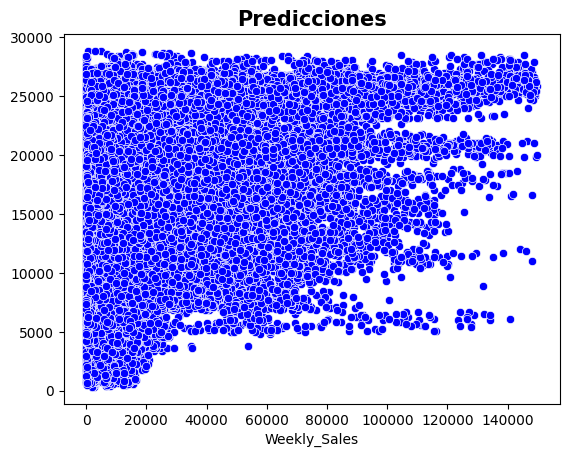

In [45]:
# Grafico con las predicciones
Y_pred = linreg.predict(x_test)
sns.scatterplot(x=Y_test , y=Y_pred, color="blue")
plt.title("Predicciones", fontsize=15, fontweight="bold");

In [46]:
# Guarda resultados
history = {"RegresionLineal" : [linreg, linreg.score(x_test, Y_test)]}

###Regresión con árbol de decisión

In [47]:
# Creación del modelo
model_tree = DecisionTreeRegressor(random_state=29)
# Entrenamiento del modelo
model_tree.fit(x_train, Y_train)

DecisionTreeRegressor(random_state=29)

In [48]:
# Evaluación del modelo
print("R squared of the Decision Tree Regressor on training set: {:.2%}".format(model_tree.score(x_train, Y_train)))
print("R squared of the Decision Tree Regressor on test set: {:.2%}".format(model_tree.score(x_test, Y_test)))

R squared of the Decision Tree Regressor on training set: 96.60%
R squared of the Decision Tree Regressor on test set: 95.49%


In [49]:
# Interpretación en el negocio
print(interpretacion("Árbol de decisión", x_train.columns, model_tree.score(x_test, Y_test)))

Modelo de regresión Árbol de decisión
  95.489% de la variabilidad de las ventas semanales se puede demostrar con 4 características
  Características elegidas :['Dept' 'Type' 'Size' 'Month']


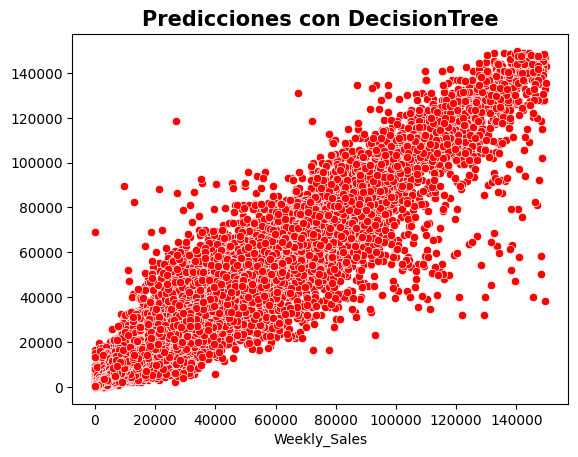

In [50]:
# Grafico con las predicciones
Y_pred_tree = model_tree.predict(x_test)
sns.scatterplot(x=Y_test , y=Y_pred_tree, color="red")
plt.title("Predicciones con DecisionTree", fontsize=15, fontweight="bold");

In [51]:
# Guarda resultados
history["DecisionTree"] = [model_tree, model_tree.score(x_test, Y_test)]

###Regresión con bosques aleatorios

In [52]:
# Creación del modelo
model_rf = RandomForestRegressor(n_estimators=100, random_state=29)
# Entrenamiento del modelo
model_rf.fit(x_train, Y_train)

RandomForestRegressor(random_state=29)

In [53]:
# Evaluación
print("R squared of the Random Forest Regressor on training set: {:.2%}".format(model_rf.score(x_train, Y_train)))
print("R squared of the Random Forest Regressor on test set: {:.2%}".format(model_rf.score(x_test, Y_test)))

R squared of the Random Forest Regressor on training set: 96.60%
R squared of the Random Forest Regressor on test set: 95.49%


In [54]:
# Interpretación en el negocio
print(interpretacion("Bosques aleatorios", x_train.columns, model_rf.score(x_test, Y_test)))

Modelo de regresión Bosques aleatorios
  95.494% de la variabilidad de las ventas semanales se puede demostrar con 4 características
  Características elegidas :['Dept' 'Type' 'Size' 'Month']


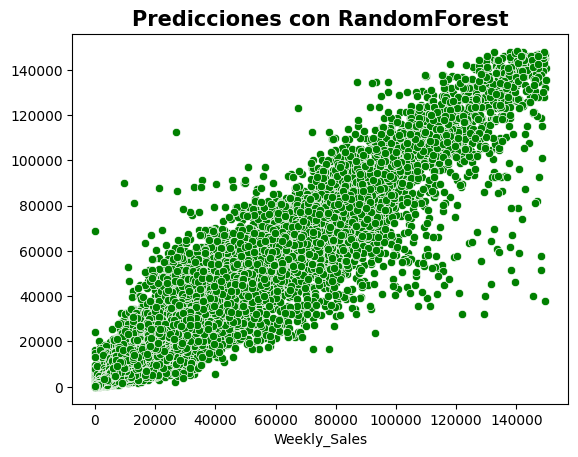

In [55]:
Y_pred_rf = model_rf.predict(x_test)
sns.scatterplot(x=Y_test , y=Y_pred_rf, color="green")
plt.title("Predicciones con RandomForest", fontsize=15, fontweight="bold");

In [56]:
# Guarda resultados
history["RandomForestRegressor"] = [model_rf, model_rf.score(x_test, Y_test)]

In [57]:
history

{'RegresionLineal': [LinearRegression(), 0.07980520471281682],
 'DecisionTree': [DecisionTreeRegressor(random_state=29), 0.9548904808553108],
 'RandomForestRegressor': [RandomForestRegressor(random_state=29),
  0.9549378856533508]}

## Variante 2 - Uso de variables numéricas y categórica


###LinearRegression

In [58]:
# Creación del modelo
linreg = LinearRegression()
# Entrenamiento del modelo
linreg.fit(X_train, y_train)

LinearRegression()

In [59]:
# Evaluación del modelo
print("R squared of the Linear Regression on training set: {:.2%}".format(linreg.score(X_train, y_train)))
print("R squared of the Linear Regression on test set: {:.2%}".format(linreg.score(X_test, y_test)))


R squared of the Linear Regression on training set: 8.10%
R squared of the Linear Regression on test set: 7.98%


In [60]:
# Interpretación en el negocio
print(interpretacion("Regresión lineal", X_train.columns, linreg.score(X_test, y_test)))


Modelo de regresión Regresión lineal
  7.981% de la variabilidad de las ventas semanales se puede demostrar con 5 características
  Características elegidas :['Dept' 'Type' 'Size' 'Event_Type' 'Month']


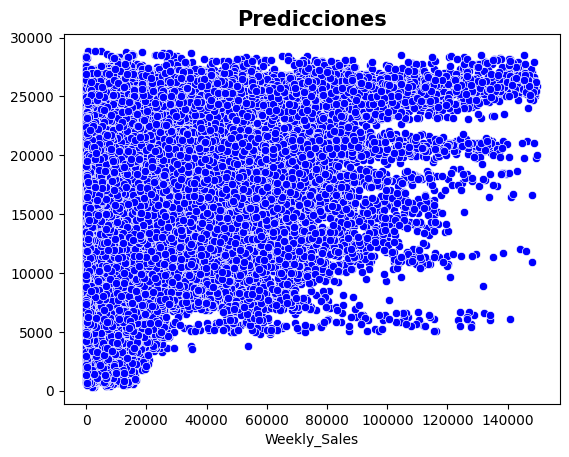

In [61]:
# Realiza predicciones
y_pred = linreg.predict(X_test)
sns.scatterplot(x=y_test , y=y_pred, color="blue")
plt.title("Predicciones", fontsize=15, fontweight="bold");

In [62]:
# Guarda resultados
history2 = {"LinearRegression" : [linreg, linreg.score(X_test, y_test)]}

###DecisionTreeRegressor

In [63]:
# Creación del modelo
model_tree = DecisionTreeRegressor(random_state=29)
# Entrenamiento del modelo
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=29)

In [64]:
# Evaluación del modelo
print("R squared of the Decision Tree Regressor on training set: {:.2%}".format(model_tree.score(X_train, y_train)))
print("R squared of the Decision Tree Regressor on test set: {:.2%}".format(model_tree.score(X_test, y_test)))


R squared of the Decision Tree Regressor on training set: 97.26%
R squared of the Decision Tree Regressor on test set: 96.07%


In [65]:
# Interpretación en el negocio
print(interpretacion("Árbol de decisión", X_train.columns, model_tree.score(X_test, y_test)))


Modelo de regresión Árbol de decisión
  96.069% de la variabilidad de las ventas semanales se puede demostrar con 5 características
  Características elegidas :['Dept' 'Type' 'Size' 'Event_Type' 'Month']


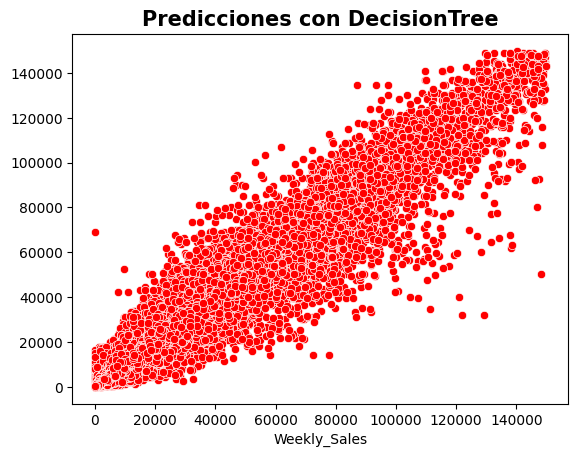

In [66]:
# Realiza predicciones
y_pred_tree = model_tree.predict(X_test)
sns.scatterplot(x=y_test , y=y_pred_tree, color="red")
plt.title("Predicciones con DecisionTree", fontsize=15, fontweight="bold");

In [67]:
# Guarda resultados
history2["DecisionTreeRegressor"] = [model_tree, model_tree.score(X_test, y_test)]

###RandomForestRegressor

In [68]:
# Creación del modelo
model_rf = RandomForestRegressor(n_estimators=100, random_state=29)
# Entrenamiento del modelo
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=29)

In [69]:
# Evaluación
print("R squared of the Random Forest Regressor on training set: {:.2%}".format(model_rf.score(X_train, y_train)))
print("R squared of the Random Forest Regressor on test set: {:.2%}".format(model_rf.score(X_test, y_test)))


R squared of the Random Forest Regressor on training set: 97.23%
R squared of the Random Forest Regressor on test set: 96.12%


In [70]:
# Interpretación en el negocio
print(interpretacion("RandomForest", X_train.columns, model_rf.score(X_test, y_test)))

Modelo de regresión RandomForest
  96.119% de la variabilidad de las ventas semanales se puede demostrar con 5 características
  Características elegidas :['Dept' 'Type' 'Size' 'Event_Type' 'Month']


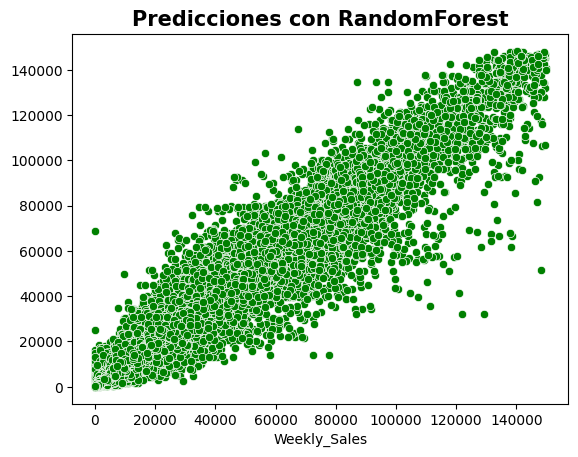

In [71]:
y_pred_rf = model_rf.predict(X_test)
sns.scatterplot(x=y_test , y=y_pred_rf, color="green")
plt.title("Predicciones con RandomForest", fontsize=15, fontweight="bold");

In [72]:
# Guarda resultados
history2["RandomForestRegressor"] = [model_rf, model_rf.score(X_test, y_test)]

In [73]:
history2

{'LinearRegression': [LinearRegression(), 0.07980747659376397],
 'DecisionTreeRegressor': [DecisionTreeRegressor(random_state=29),
  0.9606932098663874],
 'RandomForestRegressor': [RandomForestRegressor(random_state=29),
  0.9611932664977318]}

# Fase 5 - Evaluación

In [74]:
def mae_interpretacion(modelo : str, value : float):
  print(f"El modelo '{modelo}' pudo predecir el monto total del venta con un error de ± $ {value:.2f} del monto real.")

def msle_interpretacion(modelo : str, value : float):
  print(f"El modelo '{modelo}' pudo predecir el monto total del venta con un error de ± $ {value: .2%} del monto real.")

## Variante 1 - Uso sólo de variables numéricas

###LinearRegressor

In [75]:
# Evaluando el Modelo de Regresión Lineal
d = {"real": Y_test, "prediccion": Y_pred}
df_lr = pd.DataFrame(data=d)
df_lr["delta"] = df_lr["prediccion"]-df_lr["real"]
df_lr

,real,prediccion,delta
389315,15320.82,19420.944516,4100.124516
111758,2753.60,10948.180220,8194.580220
53792,9162.30,20929.496035,11767.196035
88445,1384.33,13346.520790,11962.190790
351166,6723.65,9048.139724,2324.489724
...,...,...,...
357798,52.41,9819.123844,9766.713844
407959,183.65,11861.119739,11677.469739
222131,7330.76,11942.880936,4612.120936
411309,47101.55,7857.457028,-39244.092972


In [76]:
mae_interpretacion("Regresión lineal", mean_absolute_error(Y_test, Y_pred))

El modelo 'Regresión lineal' pudo predecir el monto total del venta con un error de ± $ 13988.74 del monto real.


###DecisionTreeRegressor

In [77]:
d = {"real": Y_test, "prediccion": Y_pred_tree}
df_dt = pd.DataFrame(data=d)
df_dt["delta"] = df_dt["prediccion"]-df_dt["real"]
df_dt

,real,prediccion,delta
389315,15320.82,14034.182857,-1286.637143
111758,2753.60,3258.025714,504.425714
53792,9162.30,10051.650000,889.350000
88445,1384.33,1414.041250,29.711250
351166,6723.65,6672.940000,-50.710000
...,...,...,...
357798,52.41,61.387647,8.977647
407959,183.65,152.846111,-30.803889
222131,7330.76,9110.190000,1779.430000
411309,47101.55,54205.413000,7103.863000


In [78]:
mae_interpretacion("Árbol de decisión", mean_absolute_error(Y_test, Y_pred_tree))

El modelo 'Árbol de decisión' pudo predecir el monto total del venta con un error de ± $ 2010.95 del monto real.


In [79]:
msle_interpretacion("Árbol de decisión", mean_squared_log_error(Y_test,Y_pred_tree))

El modelo 'Árbol de decisión' pudo predecir el monto total del venta con un error de ± $  23.32% del monto real.


###RandomForest

In [80]:
d = {"real": Y_test, "prediccion": Y_pred_rf}
df_rf = pd.DataFrame(data=d)
df_rf["delta"] = df_rf["prediccion"]-df_rf["real"]
df_rf

,real,prediccion,delta
389315,15320.82,14005.407542,-1315.412458
111758,2753.60,3248.807106,495.207106
53792,9162.30,10069.547477,907.247477
88445,1384.33,1408.213050,23.883050
351166,6723.65,6623.385972,-100.264028
...,...,...,...
357798,52.41,61.167155,8.757155
407959,183.65,152.397101,-31.252899
222131,7330.76,9096.533463,1765.773463
411309,47101.55,53992.518923,6890.968923


In [81]:
mae_interpretacion("RandomForest", mean_absolute_error(Y_test, Y_pred_rf))

El modelo 'RandomForest' pudo predecir el monto total del venta con un error de ± $ 2010.74 del monto real.


In [82]:
msle_interpretacion("RandomForest", mean_squared_log_error(Y_test,Y_pred_rf))

El modelo 'RandomForest' pudo predecir el monto total del venta con un error de ± $  23.60% del monto real.


###Mejor Modelo

In [83]:
def get_bestModel( history : dict):
  # Inicializar una variable para almacenar el mayor valor
  mayor_valor = float('-inf')

  # Recorrer el diccionario
  for modelo, data in history.items():
    # Comparar el segundo elemento de la lista (data[1] almacena el score) con el mayor encontrado hasta ahora
    if data[1] > mayor_valor:
        mayor_valor = data[1]
        best_model = data[0]

  return best_model, mayor_valor, modelo

In [84]:
best_model, best_score, name_model = get_bestModel(history)
print("El mejor rendimiento es: {0:.2%} y le corresponde a {1}".format(best_score, name_model))

El mejor rendimiento es: 95.49% y le corresponde a RandomForestRegressor


###Tabla de resultados

In [85]:
#Asignación de datos basados en el mejor modelo, donde cree una nueva tabla llamada resultados
resultados = pd.DataFrame({
    'Modelo': [name_model],
    'R2 train': [best_model.score(x_train, Y_train)],
    'R2 test': [best_model.score(x_test, Y_test)],
    'MAE': [mean_absolute_error(Y_test, best_model.predict(x_test))],
    'MSLE': [mean_squared_log_error(Y_test,best_model.predict(x_test))]
})

resultados

,Modelo,R2 train,R2 test,MAE,MSLE
0,RandomForestRegressor,0.965952,0.954938,2010.743334,0.235988


###Conclusiones

El coeficiente de prueba de predicción es de un 95,49%, lo que indica que tiene un buen rendimiento con datos que aún no ha visto y solo tiene una diferencia con el entrenamiento de 1,1%, lo que demuestra que no hay gran diferencia entre el rendimiento entre datos conocidos y desconocidos, y por tanto tampoco se observa un overfitting.

En cuanto al valor MAE, este indica que en promedio hay una desviación de $2011 unidades de los valores reales, lo cual dependiendo del contexto puede ser aceptable.
Ya que hay días donde se vende bastante y otros en los que casi no se vende casi nada.

El MSLE es "bajo", esto indica que el modelo trabaja de forma medianamente precisa, ya sea con valores grandes como pequeños.

## Variante 2 - Uso de variables numéricas y categórica

###LinearRegressor

In [86]:
# Evaluando el Modelo de Regresión Lineal
d = {"real": y_test, "prediccion": y_pred}
df_lr = pd.DataFrame(data=d)
df_lr["delta"] = df_lr["prediccion"]-df_lr["real"]
df_lr

,real,prediccion,delta
389315,15320.82,19423.280410,4102.460410
111758,2753.60,10947.970045,8194.370045
53792,9162.30,20933.100570,11770.800570
88445,1384.33,13347.574117,11963.244117
351166,6723.65,8979.988083,2256.338083
...,...,...,...
357798,52.41,9825.268138,9772.858138
407959,183.65,11863.444348,11679.794348
222131,7330.76,11947.760627,4617.000627
411309,47101.55,7863.601994,-39237.948006


In [87]:
mae_interpretacion("Regresión lineal", mean_absolute_error(y_test, y_pred))

El modelo 'Regresión lineal' pudo predecir el monto total del venta con un error de ± $ 13988.75 del monto real.



###DecisionTreeRegressor

In [88]:
d = {"real": y_test, "prediccion": y_pred_tree}
df_dt = pd.DataFrame(data=d)
df_dt["delta"] = df_dt["prediccion"]-df_dt["real"]
df_dt


,real,prediccion,delta
389315,15320.82,14034.182857,-1286.637143
111758,2753.60,3258.025714,504.425714
53792,9162.30,10051.650000,889.350000
88445,1384.33,1414.041250,29.711250
351166,6723.65,6106.145000,-617.505000
...,...,...,...
357798,52.41,61.387647,8.977647
407959,183.65,152.846111,-30.803889
222131,7330.76,9110.190000,1779.430000
411309,47101.55,54205.413000,7103.863000


In [89]:
mae_interpretacion("Árbol de decisión", mean_absolute_error(y_test, y_pred_tree))

El modelo 'Árbol de decisión' pudo predecir el monto total del venta con un error de ± $ 1943.63 del monto real.


In [90]:
msle_interpretacion("Árbol de decisión", mean_squared_log_error(y_test,y_pred_tree))

El modelo 'Árbol de decisión' pudo predecir el monto total del venta con un error de ± $  23.42% del monto real.


###RandomForest

In [91]:
d = {"real": y_test, "prediccion": y_pred_rf}
df_rf = pd.DataFrame(data=d)
df_rf["delta"] = df_rf["prediccion"]-df_rf["real"]
df_rf


,real,prediccion,delta
389315,15320.82,14005.407542,-1315.412458
111758,2753.60,3248.807106,495.207106
53792,9162.30,10069.547477,907.247477
88445,1384.33,1408.213050,23.883050
351166,6723.65,6031.444131,-692.205869
...,...,...,...
357798,52.41,61.167155,8.757155
407959,183.65,152.397101,-31.252899
222131,7330.76,9096.533463,1765.773463
411309,47101.55,53992.518923,6890.968923


In [92]:
mae_interpretacion("RandomForest", mean_absolute_error(y_test, y_pred_rf))

El modelo 'RandomForest' pudo predecir el monto total del venta con un error de ± $ 1931.21 del monto real.


In [93]:
msle_interpretacion("RandomForest", mean_squared_log_error(y_test,y_pred_rf))

El modelo 'RandomForest' pudo predecir el monto total del venta con un error de ± $  23.28% del monto real.


###Mejor Modelo

In [94]:
best_model2, best_score, name_model2 = get_bestModel(history2)
print("El mejor rendimiento es: {0:.2%} y le corresponde a {1}".format(best_score, name_model))

El mejor rendimiento es: 96.12% y le corresponde a RandomForestRegressor


###Tabla de resultados

In [95]:
resultados = pd.DataFrame({
    'Modelo': [name_model2],
    'R2 train': [best_model2.score(X_train, y_train)],
    'R2 test': [best_model2.score(X_test, y_test)],
    'MAE': [mean_absolute_error(y_test, best_model2.predict(X_test))],
    'MSLE': [mean_squared_log_error(y_test,best_model2.predict(X_test))]
})

resultados

,Modelo,R2 train,R2 test,MAE,MSLE
0,RandomForestRegressor,0.972273,0.961193,1931.214115,0.232762


###Conclusiones

Respecto al modelo sin variables categoricas no existe una gran diferencia en lo que podría concluirse, tampoco se observa un sobreajuste.
Se ve un aumento en la capacidad de predecir ya sea datos conocidos y sin conocer, además de que bajaron los MAE y MSLE, indicando que existen menores errores predictivos en promedio y con valores grandes como pequeños.
Concluyendo que agregar la variable categorica hace que el proceso de predicción mejore un 1%, que no es mucho pero igualmente influye.

# Fase 6 - Deployment

Datos de ejemplo

Dept= 2;	Type= 3; Size= 155000; Event_Type=0 (Normal) ,Month=5 (Mayo)

##Variante 1 - Uso sólo de variables numéricas

In [96]:
new_tienda = [2, 3, 155000, 5]
new_tienda

[2, 3, 155000, 5]

In [97]:
x_data = pd.DataFrame(np.array(new_tienda).reshape(1,-1), columns=x_train.columns)
x_data

,Dept,Type,Size,Month
0,2,3,155000,5


In [98]:
prediction = best_model.predict(x_data)[0]
print("La tienda tendrá ventas semanales de ${:.2f}".format(prediction))

La tienda tendrá ventas semanales de $34530.22


## Variante 2 - Uso de variables numéricas y categórica

In [100]:
# Generar una nueva tienda para categoricas
new_tiendac = [2, 3, 155000, 1, 5]
new_tiendac

[2, 3, 155000, 1, 5]

In [101]:
X_data = pd.DataFrame(np.array(new_tiendac).reshape(1,-1), columns=X_train.columns)
X_data

,Dept,Type,Size,Event_Type,Month
0,2,3,155000,1,5


In [102]:
prediction = best_model2.predict(X_data)[0]
print("La tienda tendrá ventas semanales de ${:.2f}".format(prediction))

La tienda tendrá ventas semanales de $34530.22


##Generar predicciones recibiendo un .json y exportandolo


In [103]:
import json
#Descargar los json subidos al github
!wget -O entradaV1.json https://raw.githubusercontent.com/JoMULLOA/IA/refs/heads/main/EntradaV1.json
!wget -O entradaV2.json https://raw.githubusercontent.com/JoMULLOA/IA/refs/heads/main/EntradaV2.json

#Para variables solo numericas
def predExp(jsonEntrada, jsonSalida, mejorModelo):
        with open(jsonEntrada, 'r') as f:
            datos_entrada = json.load(f)

        # Convertir los datos JSON a un DataFrame
        df = pd.DataFrame(datos_entrada)
        caracteristicas = df[['Dept','Type','Size', 'Month']]
        predicciones = mejorModelo.predict(caracteristicas)
        df['Predicciones'] = predicciones
        predicciones_var1 = df.to_dict(orient='records')
        with open(jsonSalida, 'w') as f:
            json.dump(predicciones_var1, f, indent=4)

predExp('entradaV1.json', 'prediccionesV1.json', best_model)

#Para variables numericas y categorica
def predExp(jsonEntrada, jsonSalida, mejorModelo):
        with open(jsonEntrada, 'r') as f:
            datos_entrada = json.load(f)

        # Convertir los datos JSON a un DataFrame
        df = pd.DataFrame(datos_entrada)
        caracteristicas = df[['Dept','Type','Size', 'Event_Type', 'Month']]
        predicciones = mejorModelo.predict(caracteristicas)
        df['Predicciones'] = predicciones
        predicciones_var1 = df.to_dict(orient='records')
        with open(jsonSalida, 'w') as f:
            json.dump(predicciones_var1, f, indent=4)

predExp('entradaV2.json', 'prediccionesV2.json', best_model2)

--2024-10-07 07:55:18--  https://raw.githubusercontent.com/JoMULLOA/IA/refs/heads/main/EntradaV1.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 731 [text/plain]
Saving to: ‘entradaV1.json’

entradaV1.json      100%[===================>]     731  --.-KB/s    in 0s      

2024-10-07 07:55:19 (47.7 MB/s) - ‘entradaV1.json’ saved [731/731]

--2024-10-07 07:55:19--  https://raw.githubusercontent.com/JoMULLOA/IA/refs/heads/main/EntradaV2.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 920 [text/plain]
Saving to: ‘entradaV2.js

# Pregunta final

¿Qué modelo recomendaría utilizar para cumplir con el objetivo propuesto al inicio? Deberá justificar su respuesta

El objetivo principal es desarrollar modelos de regresión que permitan predecir el monto de las ventas semanales para cada tienda

Basandonos el la alta tasa de predicción de la **Regresión con Random Forest**  que es más de un 96%, en el caso donde se usa variable categorica; Y por las conclusiones de mejor modelo en ambos casos (con variable y sin variable) y las tablas de resultados generadas, este modelo sería el más indicado para este objetivo.


Sin embargo, como opinión aparte este modelo es bastante más lento de procesar que el DecisiónTree, además de que su porcentaje de predicción y posibles errores es muy parecido. Por lo tanto en casos donde se quiere trabajar mas rápido este modelo también se podría considerar.